<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/Monte_Carlo_Sim_Mechanical_Resonance_of_Eye_and_Pituitary_Gland.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

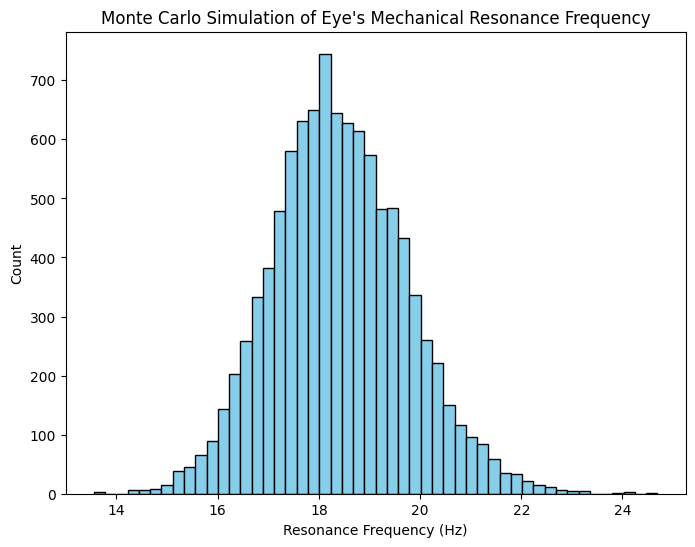

Estimated resonance frequency: 18.41 Hz ± 1.33 Hz


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Number of Monte Carlo samples
N = 10000

# Assumed mean and standard deviation for effective stiffness (k in N/m)
k_mean = 100.0      # Example value: 100 N/m
k_std = 10.0        # 10% uncertainty

# Assumed mean and standard deviation for effective mass (m in kg)
m_mean = 7.5e-3     # Example value: 7.5 grams = 0.0075 kg
m_std = 0.75e-3     # 10% uncertainty

# Set a seed for reproducibility
np.random.seed(42)

# Sample stiffness and mass from normal distributions.
# We clip the samples to ensure physically meaningful (positive) values.
k_samples = np.random.normal(k_mean, k_std, N)
m_samples = np.random.normal(m_mean, m_std, N)
k_samples = np.maximum(k_samples, 1e-6)
m_samples = np.maximum(m_samples, 1e-6)

# Calculate resonance frequency for each sample using the mass-spring formula.
frequencies = (1/(2*np.pi)) * np.sqrt(k_samples / m_samples)

# Plot a histogram of the resonance frequencies
plt.figure(figsize=(8, 6))
plt.hist(frequencies, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Resonance Frequency (Hz)")
plt.ylabel("Count")
plt.title("Monte Carlo Simulation of Eye's Mechanical Resonance Frequency")
plt.show()

# Compute and print basic statistics
mean_freq = np.mean(frequencies)
std_freq = np.std(frequencies)
print(f"Estimated resonance frequency: {mean_freq:.2f} Hz ± {std_freq:.2f} Hz")

[CPU] Time elapsed: 0.004138 seconds
[CPU] Estimated resonance frequency: 18.41 Hz ± 1.33 Hz
[GPU] Time elapsed (incl. data transfer): 2.418072 seconds
[GPU] Estimated resonance frequency: 18.41 Hz ± 1.33 Hz


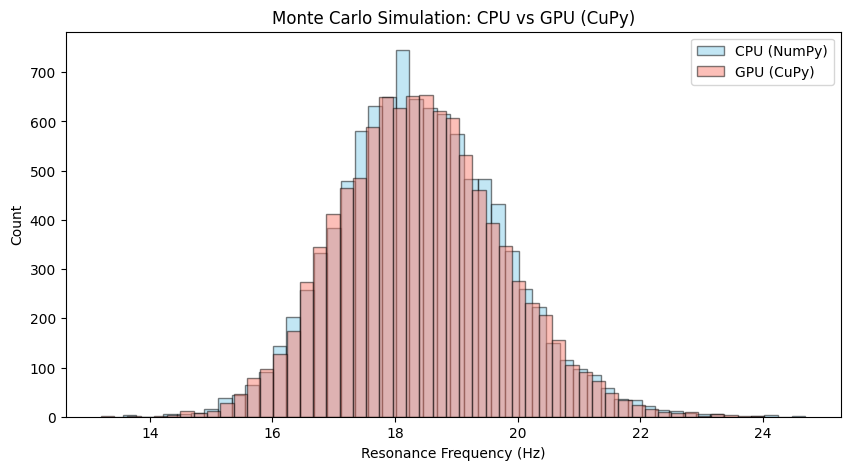

In [2]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import time

# Number of Monte Carlo samples
N = 10000

# Assumed mean and standard deviation for effective stiffness (k in N/m)
k_mean = 100.0      # Example value: 100 N/m
k_std = 10.0        # 10% uncertainty

# Assumed mean and standard deviation for effective mass (m in kg)
m_mean = 7.5e-3     # Example value: 7.5 grams = 0.0075 kg
m_std = 0.75e-3     # 10% uncertainty

# ----------------------
# CPU (NumPy) Version
# ----------------------
np.random.seed(42)
start_cpu = time.time()
# Sample stiffness and mass from normal distributions on CPU
k_cpu = np.random.normal(k_mean, k_std, N)
m_cpu = np.random.normal(m_mean, m_std, N)
# Ensure positive values
k_cpu = np.maximum(k_cpu, 1e-6)
m_cpu = np.maximum(m_cpu, 1e-6)
# Calculate resonance frequency on CPU
def compute_frequencies_cpu(k, m):
    return (1 / (2 * np.pi)) * np.sqrt(k / m)

frequencies_cpu = compute_frequencies_cpu(k_cpu, m_cpu)
time_cpu = time.time() - start_cpu

# Compute statistics on CPU
mean_freq_cpu = np.mean(frequencies_cpu)
std_freq_cpu = np.std(frequencies_cpu)

print(f"[CPU] Time elapsed: {time_cpu:.6f} seconds")
print(f"[CPU] Estimated resonance frequency: {mean_freq_cpu:.2f} Hz ± {std_freq_cpu:.2f} Hz")

# ----------------------
# GPU (CuPy) Version
# ----------------------
# Transfer mean and std to GPU constants
cp.random.seed(42)
start_gpu = time.time()
# Sample stiffness and mass from normal distributions on GPU
k_gpu = cp.random.normal(k_mean, k_std, N)
m_gpu = cp.random.normal(m_mean, m_std, N)
# Ensure positive values
k_gpu = cp.maximum(k_gpu, 1e-6)
m_gpu = cp.maximum(m_gpu, 1e-6)
# Calculate resonance frequency on GPU
def compute_frequencies_gpu(k, m):
    return (1 / (2 * cp.pi)) * cp.sqrt(k / m)

frequencies_gpu = compute_frequencies_gpu(k_gpu, m_gpu)
# Transfer results back to CPU
frequencies_gpu_cpu = cp.asnumpy(frequencies_gpu)
time_gpu = time.time() - start_gpu

# Compute statistics on GPU-computed values
mean_freq_gpu = np.mean(frequencies_gpu_cpu)
std_freq_gpu = np.std(frequencies_gpu_cpu)

print(f"[GPU] Time elapsed (incl. data transfer): {time_gpu:.6f} seconds")
print(f"[GPU] Estimated resonance frequency: {mean_freq_gpu:.2f} Hz ± {std_freq_gpu:.2f} Hz")

# ----------------------
# Plot comparison histogram
# ----------------------
plt.figure(figsize=(10, 5))
plt.hist(frequencies_cpu, bins=50, alpha=0.5, label='CPU (NumPy)', color='skyblue', edgecolor='black')
plt.hist(frequencies_gpu_cpu, bins=50, alpha=0.5, label='GPU (CuPy)', color='salmon', edgecolor='black')
plt.xlabel("Resonance Frequency (Hz)")
plt.ylabel("Count")
plt.title("Monte Carlo Simulation: CPU vs GPU (CuPy)")
plt.legend()
plt.show()


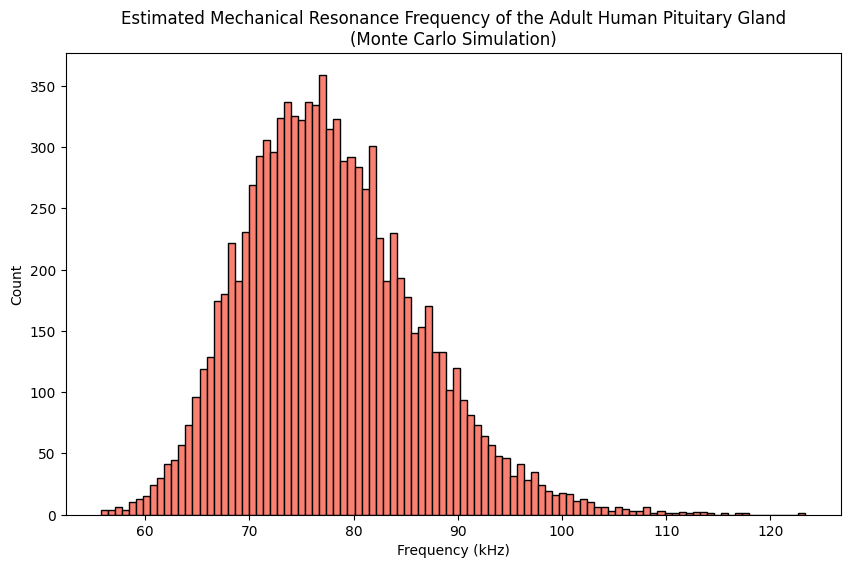

Mean Resonance Frequency: 77.86 kHz
Standard Deviation: 8.34 kHz


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for mechanical properties
sound_speed_mean = 1540  # Mean speed of sound in soft tissue (m/s)
sound_speed_std = 50     # Standard deviation in speed (m/s)

# Assumed size parameters for an adult human pituitary gland
size_mean = 0.01   # Mean effective diameter in meters (10 mm)
size_std = 0.001   # Standard deviation in size (m)

num_samples = 10000  # Number of Monte Carlo samples

# Generate random samples for size and speed of sound
sizes = np.random.normal(size_mean, size_std, num_samples)
sound_speeds = np.random.normal(sound_speed_mean, sound_speed_std, num_samples)

# Estimate mechanical resonance frequencies using f = v / (2 * L)
frequencies = sound_speeds / (2 * sizes)  # Frequency in Hz

# Plot the distribution of resonance frequencies (converted to kHz)
plt.figure(figsize=(10, 6))
plt.hist(frequencies / 1e3, bins=100, color='salmon', edgecolor='black')
plt.title("Estimated Mechanical Resonance Frequency of the Adult Human Pituitary Gland\n(Monte Carlo Simulation)")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Count")
plt.show()

# Summary statistics
mean_frequency = np.mean(frequencies)
std_frequency = np.std(frequencies)
mean_frequency_khz = mean_frequency / 1e3  # Convert to kHz
std_frequency_khz = std_frequency / 1e3

print("Mean Resonance Frequency: {:.2f} kHz".format(mean_frequency_khz))
print("Standard Deviation: {:.2f} kHz".format(std_frequency_khz))

[CPU] Time elapsed: 0.001992 seconds
[CPU] Mean Resonance Frequency: 77.85 kHz ± 8.48 kHz
[GPU] Time elapsed (incl. data transfer): 0.002010 seconds
[GPU] Mean Resonance Frequency: 77.91 kHz ± 8.51 kHz


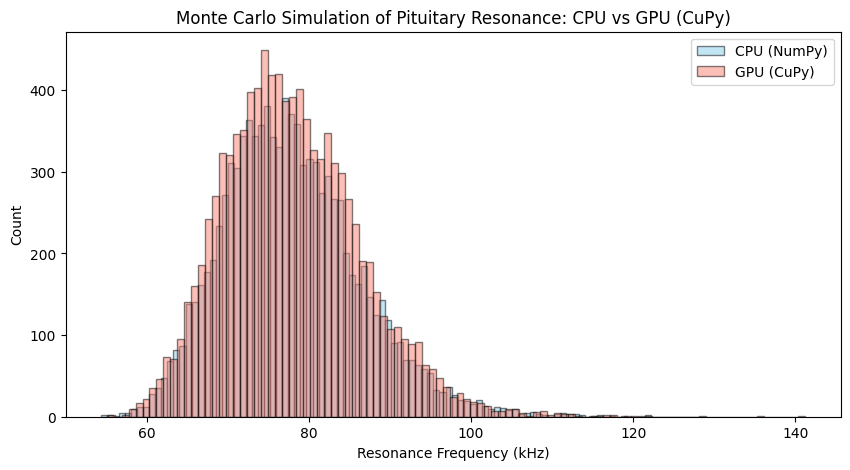

In [6]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import time

# Number of Monte Carlo samples
num_samples = 10000

# Constants for mechanical properties
sound_speed_mean = 1540  # Mean speed of sound in soft tissue (m/s)
sound_speed_std = 50     # Standard deviation in speed (m/s)

# Assumed size parameters for an adult human pituitary gland
size_mean = 0.01   # Mean effective diameter in meters (10 mm)
size_std = 0.001   # Standard deviation in size (m)

# ----------------------
# CPU (NumPy) Version
# ----------------------
np.random.seed(42)
start_cpu = time.time()
# Generate random samples on CPU
sizes_cpu = np.random.normal(size_mean, size_std, num_samples)
sound_speeds_cpu = np.random.normal(sound_speed_mean, sound_speed_std, num_samples)
# Ensure positive values for sizes and sound speeds
sizes_cpu = np.maximum(sizes_cpu, 1e-6)
sound_speeds_cpu = np.maximum(sound_speeds_cpu, 1e-6)
# Calculate resonance frequencies on CPU: f = v / (2 * L)
frequencies_cpu = sound_speeds_cpu / (2 * sizes_cpu)
# Compute statistics on CPU
mean_freq_cpu = np.mean(frequencies_cpu)
std_freq_cpu = np.std(frequencies_cpu)
time_cpu = time.time() - start_cpu

print(f"[CPU] Time elapsed: {time_cpu:.6f} seconds")
print(f"[CPU] Mean Resonance Frequency: {mean_freq_cpu/1e3:.2f} kHz ± {std_freq_cpu/1e3:.2f} kHz")

# ----------------------
# GPU (CuPy) Version
# ----------------------
cp.random.seed(42)
start_gpu = time.time()
# Generate random samples on GPU
sizes_gpu = cp.random.normal(size_mean, size_std, num_samples)
sound_speeds_gpu = cp.random.normal(sound_speed_mean, sound_speed_std, num_samples)
# Ensure positive values
sizes_gpu = cp.maximum(sizes_gpu, 1e-6)
sound_speeds_gpu = cp.maximum(sound_speeds_gpu, 1e-6)
# Calculate resonance frequencies on GPU: f = v / (2 * L)
frequencies_gpu = sound_speeds_gpu / (2 * sizes_gpu)
# Transfer results back to CPU
frequencies_gpu_cpu = cp.asnumpy(frequencies_gpu)
# Compute statistics on GPU results
mean_freq_gpu = np.mean(frequencies_gpu_cpu)
std_freq_gpu = np.std(frequencies_gpu_cpu)
time_gpu = time.time() - start_gpu

print(f"[GPU] Time elapsed (incl. data transfer): {time_gpu:.6f} seconds")
print(f"[GPU] Mean Resonance Frequency: {mean_freq_gpu/1e3:.2f} kHz ± {std_freq_gpu/1e3:.2f} kHz")

# ----------------------
# Plot comparison histogram
# ----------------------
plt.figure(figsize=(10, 5))
plt.hist(frequencies_cpu / 1e3, bins=100, alpha=0.5, label='CPU (NumPy)', color='skyblue', edgecolor='black')
plt.hist(frequencies_gpu_cpu / 1e3, bins=100, alpha=0.5, label='GPU (CuPy)', color='salmon', edgecolor='black')
plt.xlabel("Resonance Frequency (kHz)")
plt.ylabel("Count")
plt.title("Monte Carlo Simulation of Pituitary Resonance: CPU vs GPU (CuPy)")
plt.legend()
plt.show()
